# 04 - Modeling: Engineered Features

**Goal:** Re-run the same two models from the baseline notebook (Logistic Regression + Gradient Boosting) 
but now on the full engineered feature matrix from `features.parquet`. 
Compare val AUC-ROC directly against the baseline to measure how much the feature engineering buys us.

**Same pipeline, new features.** Keeping the models identical ensures any performance difference 
is attributable to feature quality, not model choice.

> Train: 500 customers (21 suspicious) | Val: 200 customers (9 suspicious) | Test: 500 (labels withheld)

---
## 0. Setup

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
OUT = '../data/'

---
## 1. Load Feature Matrix

Loading `features.parquet` produced by `02_feature_engineering.ipynb`. 
All 64 engineered features are ready Ă˘â‚¬â€ť no further transformation needed here except 
converting bool columns to int for sklearn compatibility and confirming no nulls remain.

In [87]:
df = pd.read_parquet(OUT + 'features.parquet')

# Convert bool columns to int (sklearn does not accept bool dtype)
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

# All columns except metadata
feature_cols = [c for c in df.columns
                if c not in ['customer_id', 'suspicious_activity_confirmed', 'split']
                and df[c].dtype != object]

print(f'Feature columns: {len(feature_cols)}')
print(f'Nulls in features: {df[feature_cols].isnull().sum().sum()}')

Feature columns: 60
Nulls in features: 58


In [88]:
train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'val'].copy()

X_train = train[feature_cols]
y_train = train['suspicious_activity_confirmed'].astype(int)

X_val = val[feature_cols]
y_val = val['suspicious_activity_confirmed'].astype(int)

print(f'Train: {len(X_train)} rows, {y_train.sum()} suspicious ({y_train.mean():.1%})')
print(f'Val:   {len(X_val)} rows, {y_val.sum()} suspicious ({y_val.mean():.1%})')

Train: 500 rows, 21 suspicious (4.2%)
Val:   200 rows, 9 suspicious (4.5%)


---
## 2. Model 1 Ă˘â‚¬â€ť Logistic Regression

Same settings as the baseline: `class_weight='balanced'`, scaled features. 
With 64 features and only 21 positives we are in a high-dimensional regime for logistic regression Ă˘â‚¬â€ť 
L2 regularisation (default in sklearn) will shrink weak coefficients toward zero, 
which is appropriate here.

In [89]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

lr_val_proba   = lr.predict_proba(X_val_s)[:, 1]
lr_train_proba = lr.predict_proba(X_train_s)[:, 1]
lr_auc         = roc_auc_score(y_val, lr_val_proba)
lr_prauc       = average_precision_score(y_val, lr_val_proba)
lr_train_auc   = roc_auc_score(y_train, lr_train_proba)

print(f'Logistic Regression — Train AUC: {lr_train_auc:.4f}  Val AUC-ROC: {lr_auc:.4f}  PR-AUC: {lr_prauc:.4f}')
print(f'                      Train-Val gap: {lr_train_auc - lr_auc:+.4f}')

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\kubad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\kubad\AppData\Local\Temp\ipykernel_33020\157901255.py", line 6, in <module>
    lr.fit(X_train_s, y_train)
  File "C:\Users\kubad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py", line 1152, in wrapper
    ...             self.estimator_ = LogisticRegression()
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kubad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py", line 1208, in fit
    raise ValueError(
  File "C:\Users\kubad\AppData\Local\Packages\PythonS

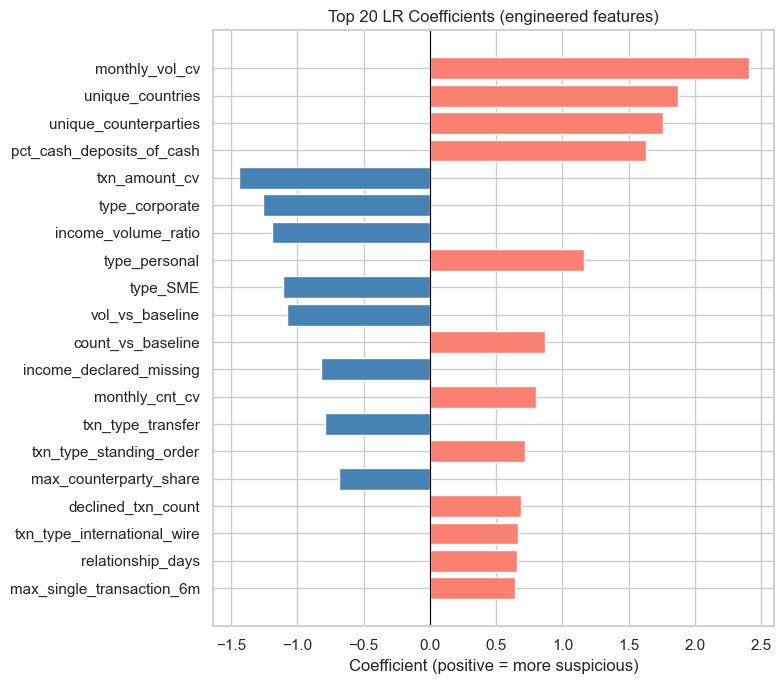

In [ ]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 LR Coefficients (engineered features)')
ax.set_xlabel('Coefficient (positive = more suspicious)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 3. Model 2 Ă˘â‚¬â€ť Gradient Boosting

Same hyperparameters as the baseline: shallow trees (`max_depth=3`), `n_estimators=100`, 
`learning_rate=0.05`, `subsample=0.8`. 
With 64 features vs 18 in the baseline, gradient boosting has more combinations to explore Ă˘â‚¬â€ť 
if the engineered features carry real signal, this model should show the largest improvement.

In [ ]:
sample_weight = np.where(y_train == 1,
    len(y_train) / (2 * y_train.sum()),
    len(y_train) / (2 * (len(y_train) - y_train.sum()))
)

gb = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=5, random_state=42
)
gb.fit(X_train, y_train, sample_weight=sample_weight)

gb_val_proba   = gb.predict_proba(X_val)[:, 1]
gb_train_proba = gb.predict_proba(X_train)[:, 1]
gb_auc         = roc_auc_score(y_val, gb_val_proba)
gb_prauc       = average_precision_score(y_val, gb_val_proba)
gb_train_auc   = roc_auc_score(y_train, gb_train_proba)

print(f'Gradient Boosting   — Train AUC: {gb_train_auc:.4f}  Val AUC-ROC: {gb_auc:.4f}  PR-AUC: {gb_prauc:.4f}')
print(f'                      Train-Val gap: {gb_train_auc - gb_auc:+.4f}')

Gradient Boosting   — Train AUC: 1.0000  Val AUC-ROC: 0.8450  PR-AUC: 0.3727
                      Train-Val gap: +0.1550


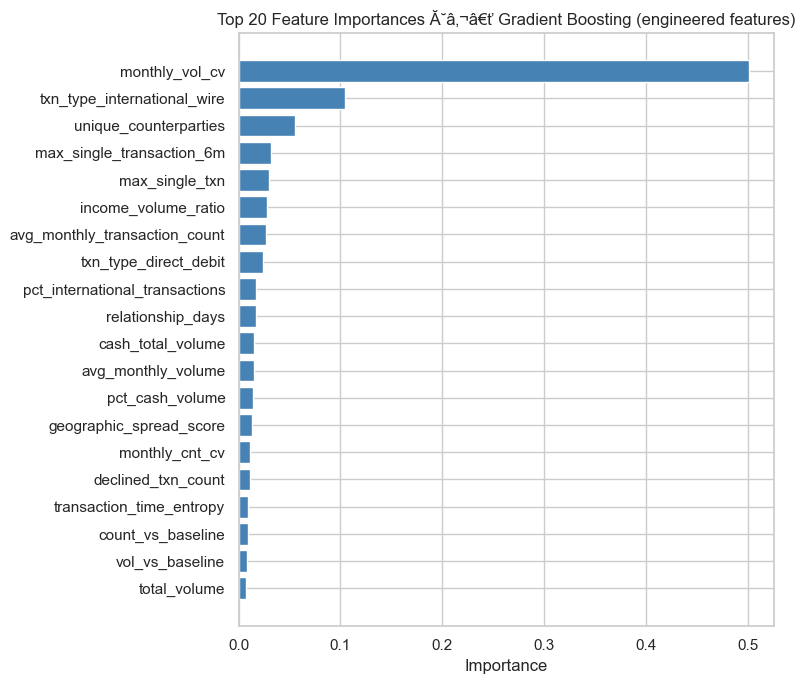

In [ ]:
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances Ă˘â‚¬â€ť Gradient Boosting (engineered features)')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Model 3 — Random Forest

**Why:** Random forest builds many shallow decision trees on bootstrapped subsets of the data and averages their predictions. This makes it naturally resistant to overfitting on small datasets — each tree sees a different random subset of training examples and features, so no single noisy positive can dominate.

With only 21 positives, random forest's variance reduction through averaging is a real advantage over a single gradient boosting sequence. Feature importances are identical in interpretation to gradient boosting and easy to explain to compliance analysts. `class_weight='balanced_subsample'` reweights each bootstrap sample independently, which handles imbalance better than a global weight on a dataset this small.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_val_proba  = rf.predict_proba(X_val)[:, 1]
rf_train_proba = rf.predict_proba(X_train)[:, 1]
rf_auc        = roc_auc_score(y_val, rf_val_proba)
rf_prauc      = average_precision_score(y_val, rf_val_proba)
rf_train_auc  = roc_auc_score(y_train, rf_train_proba)

print(f'Random Forest — Train AUC: {rf_train_auc:.4f}  Val AUC-ROC: {rf_auc:.4f}  PR-AUC: {rf_prauc:.4f}')
print(f'               Train-Val gap: {rf_train_auc - rf_auc:+.4f}')

Random Forest — Train AUC: 1.0000  Val AUC-ROC: 0.8485  PR-AUC: 0.4071
               Train-Val gap: +0.1515


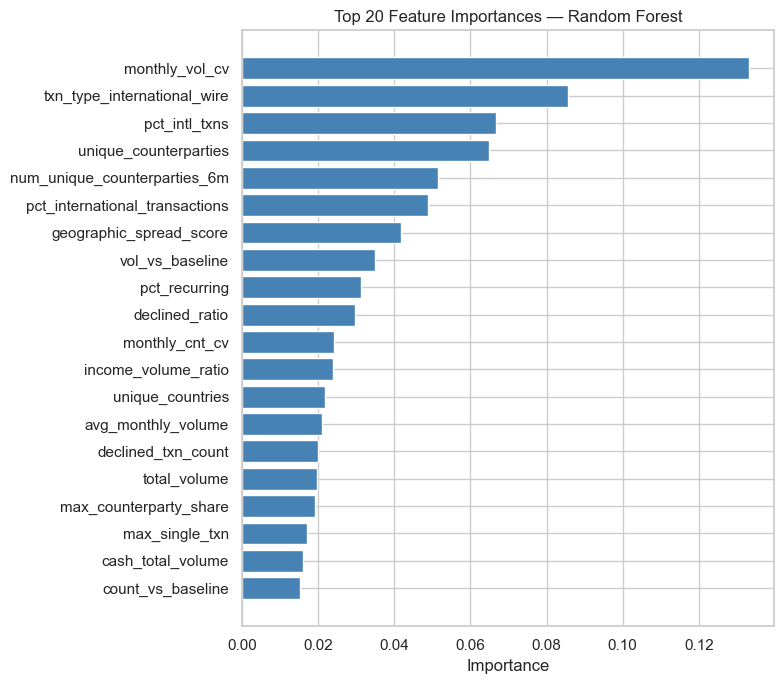

In [ ]:
rf_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(rf_imp['feature'], rf_imp['importance'], color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances — Random Forest')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5. Model 4 — XGBoost

**Why:** XGBoost is a faster, more regularised implementation of gradient boosting. Key differences from sklearn's GradientBoostingClassifier:

- `scale_pos_weight` directly tells the model the ratio of negative to positive examples, handling imbalance more explicitly than sample weighting
- `reg_alpha` (L1) and `reg_lambda` (L2) add feature-level regularisation, shrinking unimportant features toward zero — useful with 64 features and 21 positives
- **Early stopping** — we set `n_estimators=500` but pass `eval_set=[(X_val, y_val)]` and `early_stopping_rounds=20`. XGBoost stops adding trees the moment val AUC stops improving for 20 consecutive rounds. This means the model can never overfit beyond the point of peak val performance.
- Native SHAP support for per-prediction explanations, which we will use in the app

`scale_pos_weight` is set to the ratio of clean to suspicious examples in the training set.

In [ ]:
from xgboost import XGBClassifier

scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())
print(f'scale_pos_weight: {scale_pos} ({(y_train==0).sum()} clean / {(y_train==1).sum()} suspicious)')

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=20,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print(f'Best iteration: {xgb.best_iteration}  (of 500 max)')

xgb_val_proba   = xgb.predict_proba(X_val)[:, 1]
xgb_train_proba = xgb.predict_proba(X_train)[:, 1]
xgb_auc         = roc_auc_score(y_val, xgb_val_proba)
xgb_prauc       = average_precision_score(y_val, xgb_val_proba)
xgb_train_auc   = roc_auc_score(y_train, xgb_train_proba)

print(f'XGBoost       — Train AUC: {xgb_train_auc:.4f}  Val AUC-ROC: {xgb_auc:.4f}  PR-AUC: {xgb_prauc:.4f}')
print(f'               Train-Val gap: {xgb_train_auc - xgb_auc:+.4f}')

scale_pos_weight: 22 (479 clean / 21 suspicious)
Best iteration: 7  (of 500 max)
XGBoost       — Train AUC: 0.9947  Val AUC-ROC: 0.8886  PR-AUC: 0.3600
               Train-Val gap: +0.1061


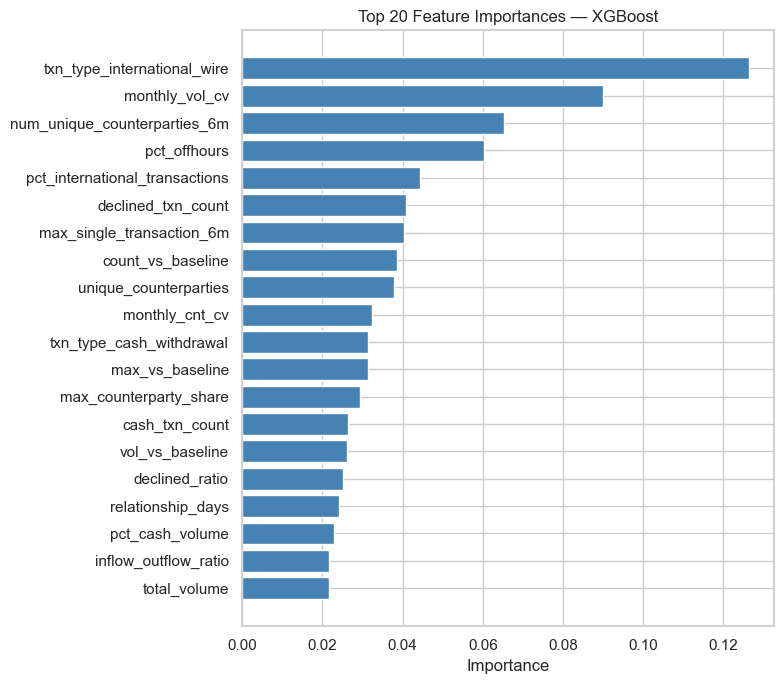

In [ ]:
xgb_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(xgb_imp['feature'], xgb_imp['importance'], color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances — XGBoost')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Overfitting Check

**Why this matters:** We have 21 positive training examples and many features. 
A model can easily memorise the training positives without learning generalisable patterns. 
The symptom is a large gap between train and val AUC-ROC.

**Train vs val AUC-ROC:** If train >> val, the model has overfit. 
A gap of more than ~0.10 on a dataset this small is worth investigating.

**Stratified K-Fold cross-validation:** Instead of relying on a single train/val split, 
we run 5-fold CV on the training data only. With 21 positives across 5 folds, 
each fold has ~4 positives â€” the scores will have high variance, but the mean and std 
tell us whether performance is consistent or lucky. A high std means the model is 
sensitive to which specific customers end up in each fold.

In [ ]:
print('Train vs Val AUC-ROC gap:')
for name, t, v in [
    ('Logistic Regression', lr_train_auc,  lr_auc),
    ('Gradient Boosting  ', gb_train_auc,  gb_auc),
    ('Random Forest      ', rf_train_auc,  rf_auc),
    ('XGBoost            ', xgb_train_auc, xgb_auc),
]:
    print(f'  {name}  train={t:.4f}  val={v:.4f}  gap={t-v:+.4f}')
print()
print('Rule of thumb: gap > 0.10 suggests overfitting.')

Train vs Val AUC-ROC gap:
  Logistic Regression  train=0.9970  val=0.8464  gap=+0.1506
  Gradient Boosting    train=1.0000  val=0.8450  gap=+0.1550
  Random Forest        train=1.0000  val=0.8485  gap=+0.1515
  XGBoost              train=0.9947  val=0.8886  gap=+0.1061

Rule of thumb: gap > 0.10 suggests overfitting.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_train_s, y_train, cv=cv, scoring='roc_auc'
)

gb_cv_scores = cross_val_score(
    GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=5, random_state=42
    ),
    X_train, y_train, cv=cv, scoring='roc_auc'
)

rf_cv_scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=500, max_depth=5, min_samples_leaf=3,
        max_features='sqrt', class_weight='balanced_subsample',
        random_state=42, n_jobs=-1
    ),
    X_train, y_train, cv=cv, scoring='roc_auc'
)

xgb_cv_scores = cross_val_score(
    XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, eval_metric='auc', verbosity=0
    ),
    X_train, y_train, cv=cv, scoring='roc_auc'
)

print('5-Fold Stratified CV on train split (AUC-ROC):')
for name, scores in [
    ('Logistic Regression', lr_cv_scores),
    ('Gradient Boosting  ', gb_cv_scores),
    ('Random Forest      ', rf_cv_scores),
    ('XGBoost            ', xgb_cv_scores),
]:
    print(f'  {name}  mean={scores.mean():.4f}  std={scores.std():.4f}  folds={[round(s,3) for s in scores]}')

5-Fold Stratified CV on train split (AUC-ROC):
  Logistic Regression  mean=0.9078  std=0.0486  folds=[0.971, 0.896, 0.953, 0.839, 0.88]
  Gradient Boosting    mean=0.9385  std=0.0361  folds=[0.977, 0.932, 0.982, 0.888, 0.914]
  Random Forest        mean=0.9341  std=0.0482  folds=[0.992, 0.927, 0.982, 0.862, 0.907]
  XGBoost              mean=0.9339  std=0.0447  folds=[0.99, 0.904, 0.987, 0.901, 0.888]


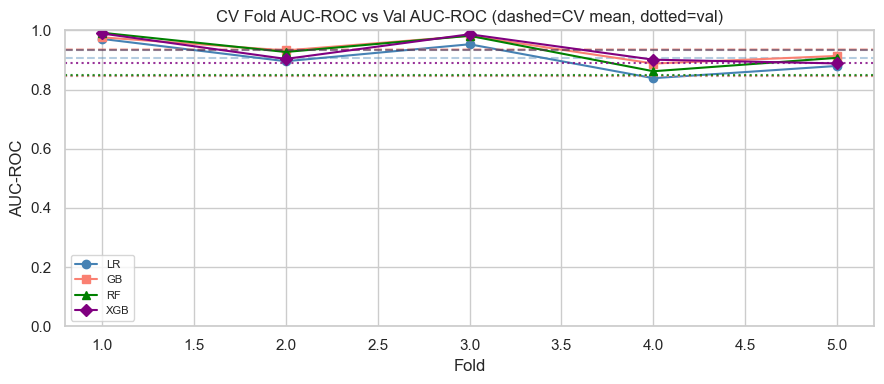

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(1, 6)
for name, scores, val_score, color, marker in [
    ('LR',  lr_cv_scores,  lr_auc,  'steelblue', 'o'),
    ('GB',  gb_cv_scores,  gb_auc,  'salmon',    's'),
    ('RF',  rf_cv_scores,  rf_auc,  'green',     '^'),
    ('XGB', xgb_cv_scores, xgb_auc, 'purple',    'D'),
]:
    ax.plot(x, scores, marker=marker, linestyle='-', color=color, label=name)
    ax.axhline(scores.mean(), color=color, linestyle='--', alpha=0.4)
    ax.axhline(val_score,     color=color, linestyle=':',  alpha=0.8)

ax.set_title('CV Fold AUC-ROC vs Val AUC-ROC (dashed=CV mean, dotted=val)')
ax.set_xlabel('Fold')
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 4. Compare: Baseline vs Engineered Features

Paste in the baseline scores from `03_modeling.ipynb` to see the delta directly. 
The PR curve matters more than ROC given the 4.5% class imbalance.

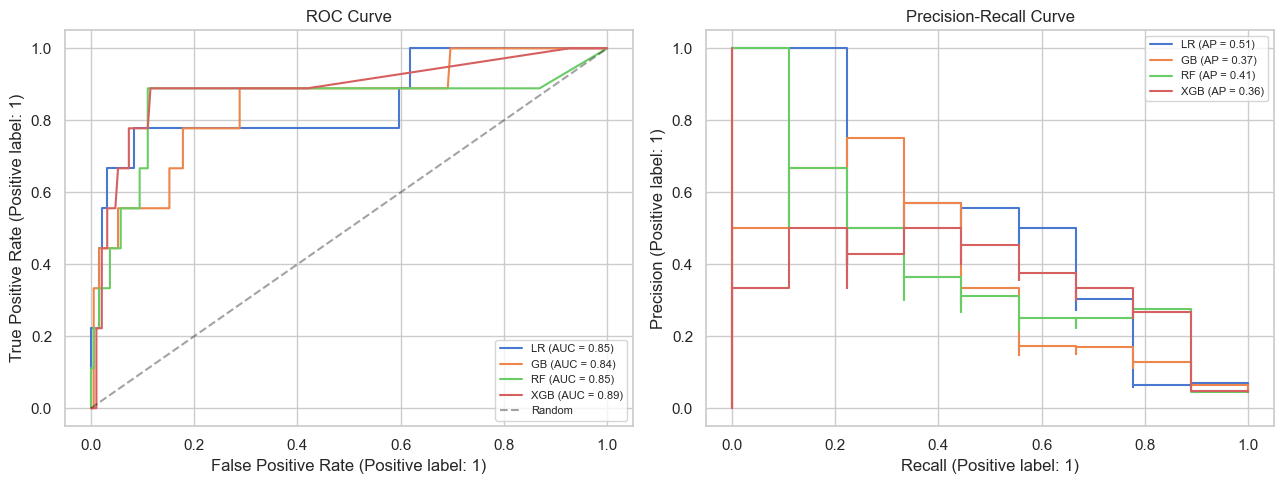

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba, color in [
    ('LR',  lr_val_proba,  'steelblue'),
    ('GB',  gb_val_proba,  'salmon'),
    ('RF',  rf_val_proba,  'green'),
    ('XGB', xgb_val_proba, 'purple'),
]:
    RocCurveDisplay.from_predictions(y_val, proba, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_val, proba, name=name, ax=axes[1])

axes[0].plot([0,1],[0,1],'k--',alpha=0.4,label='Random')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=8)
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
print('=' * 60)
print('MODEL SUMMARY')
print('=' * 60)
print(f'{"Model":<30} {"Train AUC":>10} {"Val AUC":>10} {"PR-AUC":>8} {"Gap":>8}')
print('-' * 60)
for name, t_auc, v_auc, prauc in [
    ('Logistic Regression',  lr_train_auc,  lr_auc,  lr_prauc),
    ('Gradient Boosting',    gb_train_auc,  gb_auc,  gb_prauc),
    ('Random Forest',        rf_train_auc,  rf_auc,  rf_prauc),
    ('XGBoost',              xgb_train_auc, xgb_auc, xgb_prauc),
]:
    gap = t_auc - v_auc
    print(f'{name:<30} {t_auc:>10.4f} {v_auc:>10.4f} {prauc:>8.4f} {gap:>+8.4f}')
print('=' * 60)
print('Gap > 0.10 suggests overfitting.')

MODEL SUMMARY
Model                           Train AUC    Val AUC   PR-AUC      Gap
------------------------------------------------------------
Logistic Regression                0.9970     0.8464   0.5075  +0.1506
Gradient Boosting                  1.0000     0.8450   0.3727  +0.1550
Random Forest                      1.0000     0.8485   0.4071  +0.1515
XGBoost                            0.9947     0.8886   0.3600  +0.1061
Gap > 0.10 suggests overfitting.


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calibrated threshold: flag top ~4.5% of val customers (matching val prevalence)
val_prevalence = y_val.mean()
val_threshold  = float(pd.Series(xgb_val_proba).quantile(1 - val_prevalence))
print(f'Val prevalence: {val_prevalence:.1%}  →  threshold: {val_threshold:.4f}')
print()

models = [
    ('Logistic Regression', lr_val_proba),
    ('Gradient Boosting',   gb_val_proba),
    ('Random Forest',       rf_val_proba),
    ('XGBoost',             xgb_val_proba),
]

for name, proba in models:
    t = float(pd.Series(proba).quantile(1 - val_prevalence))
    preds = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f2        = (5 * precision * recall) / (4 * precision + recall) if (precision + recall) > 0 else 0
    print(f'{name}')
    print(f'  Threshold : {t:.4f}  |  Flagged: {preds.sum()} of {len(preds)}')
    print(f'  TP={tp}  FP={fp}  TN={tn}  FN={fn}')
    print(f'  Precision : {precision:.2%}   Recall: {recall:.2%}   F2: {f2:.3f}')
    print()

---
## 5. Generate Submission File

Once we are satisfied with val performance, retrain the best model on train+val combined 
and generate `predictions.csv` for the 500 organiser test customers.

**Important:** only run this cell when we have decided on the final model. 
Retraining on more data (train+val = 700 customers, 30 suspicious) should improve generalisation.

In [ ]:
# Retrain XGBoost on train+val combined and generate submission.
# We do NOT use xgb.best_iteration here — early stopping fired at iteration 7
# because 9 val positives produce a noisy AUC curve. With 30 positives in
# train+val combined, overfitting is less of a concern, so we use n_estimators=100.
train_val = df[df['split'].isin(['train', 'val'])].copy()
test      = df[df['split'] == 'test'].copy()

X_trainval = train_val[feature_cols]
y_trainval = train_val['suspicious_activity_confirmed'].astype(int)
X_test     = test[feature_cols]

final_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=int((y_trainval == 0).sum() / (y_trainval == 1).sum()),
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
final_model.fit(X_trainval, y_trainval)

test_proba = final_model.predict_proba(X_test)[:, 1]

# Threshold calibrated to train+val suspicious prevalence
prevalence = y_trainval.mean()
threshold  = float(pd.Series(test_proba).quantile(1 - prevalence))
print(f'Prevalence in train+val: {prevalence:.2%}  →  threshold: {threshold:.4f}')
print(f'Score range: {test_proba.min():.4f} – {test_proba.max():.4f}')

submission = pd.DataFrame({
    'customer_id': test['customer_id'].values,
    'predicted_probability': test_proba.round(4),
    'predicted_suspicious_activity': (test_proba >= threshold).astype(int),
})
submission = submission.sort_values('predicted_probability', ascending=False).reset_index(drop=True)

out_csv  = OUT + 'predictions.csv'
out_xlsx = OUT + 'predictions.xlsx'
submission.to_csv(out_csv, index=False)
submission.to_excel(out_xlsx, index=False)

n_flagged = submission['predicted_suspicious_activity'].sum()
print(f'Saved predictions.csv and predictions.xlsx — {len(submission)} rows')
print(f'Flagged as suspicious: {n_flagged} ({n_flagged/len(submission):.1%})')
print(submission[['customer_id','predicted_probability','predicted_suspicious_activity']].head(10))

Prevalence in train+val: 4.29%  →  threshold: 0.5265
Score range: 0.0027 – 0.9619
Saved predictions.csv and predictions.xlsx — 500 rows
Flagged as suspicious: 22 (4.4%)
  customer_id  predicted_probability  predicted_suspicious_activity
0   CUST_0197                 0.9619                              1
1   CUST_0189                 0.9515                              1
2   CUST_0505                 0.9387                              1
3   CUST_0606                 0.9337                              1
4   CUST_0180                 0.7928                              1
5   CUST_0440                 0.7666                              1
6   CUST_0237                 0.7556                              1
7   CUST_0963                 0.7332                              1
8   CUST_0077                 0.7327                              1
9   CUST_0126                 0.7277                              1


---
## 6. Internal Scored Output with SHAP Explanations

Generates `scored_all.csv` covering all 1200 customers — same structure as the pipeline output in the other branch, but with **per-customer SHAP top-3 features** instead of global importances.

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value *for that specific prediction*. The top-3 features are the ones that pushed that customer's score highest, not the globally important features. This is what a compliance analyst actually needs to investigate an alert.

In [ ]:
import xgboost

# Score all 1200 customers with the final model
X_all   = df[feature_cols]
all_proba = final_model.predict_proba(X_all)[:, 1]

# Per-customer top-3 features using XGBoost's predict_contribs (SHAP-style marginal contributions).
# Returns shape (n, n_features+1) — last column is the bias term, we drop it.
contribs = final_model.get_booster().predict(xgboost.DMatrix(X_all), pred_contribs=True)
contrib_df = pd.DataFrame(contribs[:, :-1], columns=feature_cols)

def top_n_features(row, n=3):
    return row.abs().nlargest(n).index.tolist()

top3 = contrib_df.apply(top_n_features, axis=1, result_type='expand')
top3.columns = ['top_feature_1', 'top_feature_2', 'top_feature_3']

scored_all = pd.DataFrame({
    'customer_id':                   df['customer_id'].values,
    'split':                         df['split'].values,
    'suspicious_activity_confirmed': df['suspicious_activity_confirmed'].values,
    'predicted_probability':         all_proba.round(4),
}).reset_index(drop=True)

scored_all = pd.concat([scored_all, top3.reset_index(drop=True)], axis=1)
scored_all['rank'] = scored_all['predicted_probability'].rank(ascending=False).astype(int)
scored_all = scored_all.sort_values('rank').reset_index(drop=True)

out_path = OUT + 'scored_all.csv'
scored_all.to_csv(out_path, index=False)

print(f'Saved scored_all.csv — {len(scored_all)} customers')
print(f'Unique top_feature_1 values: {scored_all["top_feature_1"].nunique()}  (should be > 1)')
print()
print('Top 10 highest-risk customers:')
print(scored_all[['customer_id','predicted_probability','top_feature_1','top_feature_2','top_feature_3','rank']].head(10).to_string(index=False))

Saved scored_all.csv — 1200 customers
Unique top_feature_1 values: 8  (should be > 1)

Top 10 highest-risk customers:
customer_id  predicted_probability               top_feature_1         top_feature_2               top_feature_3  rank
  CUST_0117                 0.9883 txn_type_international_wire        monthly_vol_cv              declined_ratio     1
  CUST_0511                 0.9880 txn_type_international_wire        monthly_vol_cv        inflow_outflow_ratio     2
  CUST_0756                 0.9816              declined_ratio        monthly_vol_cv        inflow_outflow_ratio     3
  CUST_0553                 0.9811 txn_type_international_wire        monthly_vol_cv              declined_ratio     4
  CUST_0776                 0.9783 txn_type_international_wire        monthly_vol_cv              declined_ratio     5
  CUST_0983                 0.9778 txn_type_international_wire        monthly_vol_cv              declined_ratio     6
  CUST_0644                 0.9761 txn_type_inter